
==================== CASE: SNOWPACK_FORCED ====================

=== HS stats (time×layer, NaN + zeros removed) ===
           ΔSNOW.HS    HS2SWE.HS
count   4338.000000  3886.000000
mean       0.031057     0.034607
std        0.031912     0.029941
min        0.002161     0.000281
p25        0.010120     0.011439
median     0.020237     0.025129
p75        0.040794     0.049308
max        0.271574     0.270333

=== RHO stats (time×layer, NaN + zeros removed) ===
          ΔSNOW.RHO   HS2SWE.RHO
count   4338.000000  8507.000000
mean     314.111998   225.214177
std      104.825232   129.727586
min       76.934619   113.700000
p25      230.891717   113.700000
median   375.448510   165.759828
p75      401.258800   336.523133
max      401.258800   571.600000

=== OVB stats (time×layer, NaN + zeros removed) ===
          ΔSNOW.OVB   HS2SWE.OVB
count   4338.000000  4154.000000
mean     148.714974   141.565722
std       98.118565    99.813935
min        2.191325     0.101049
p25       63.99627

/var/folders/r5/2d5m4_zn37d74npwnbfcpcdh0000gn/T/ipykernel_6600/1389993000.py:82: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = mpl.cm.get_cmap("hsv", n_layers)


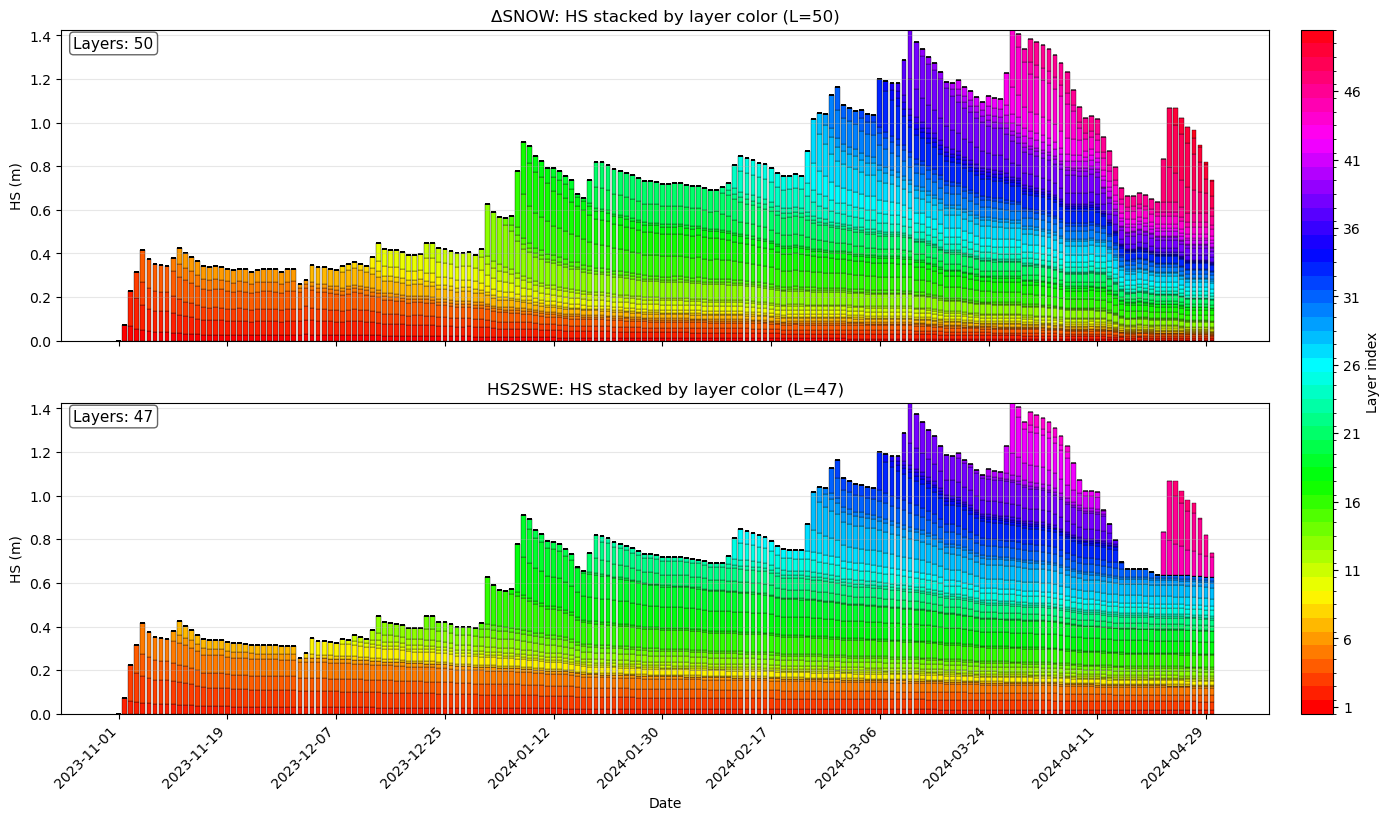

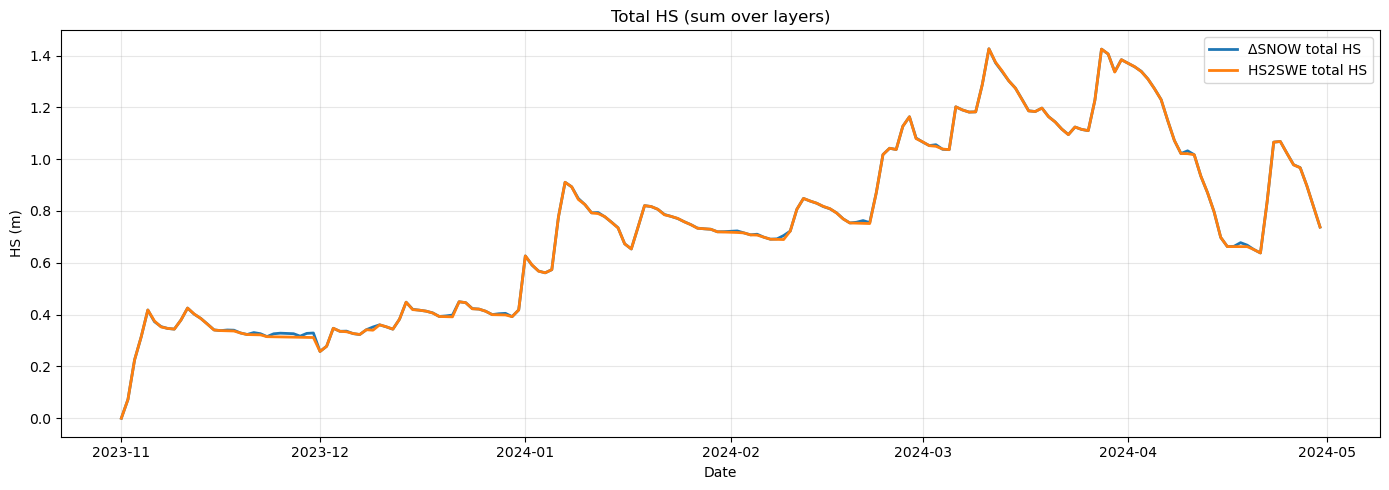

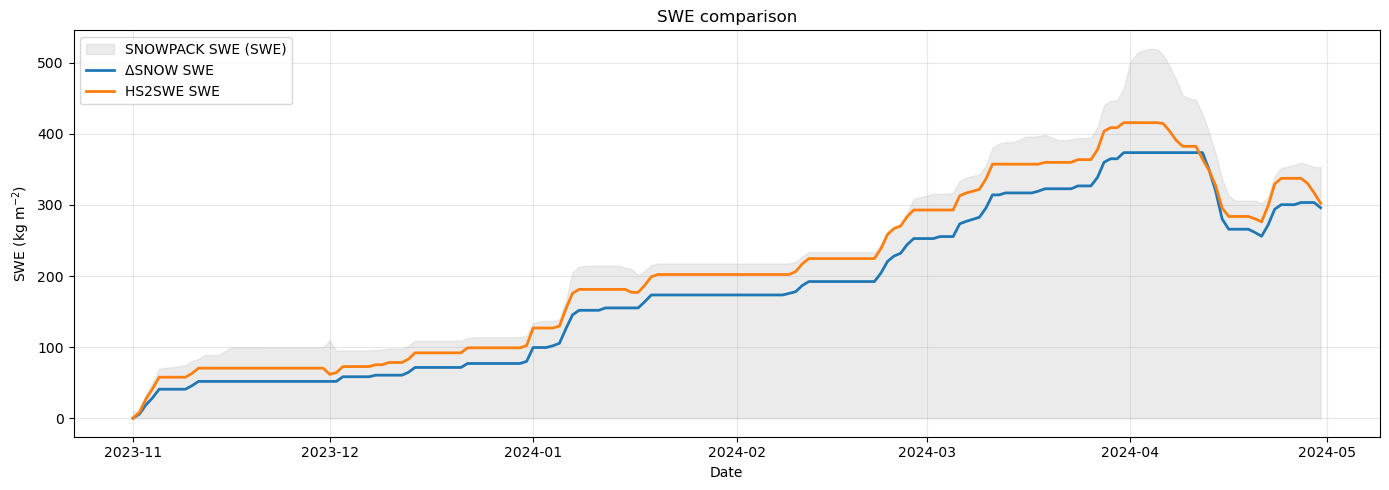

/var/folders/r5/2d5m4_zn37d74npwnbfcpcdh0000gn/T/ipykernel_6600/1389993000.py:280: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_ = mpl.cm.get_cmap(cmap_name)
/var/folders/r5/2d5m4_zn37d74npwnbfcpcdh0000gn/T/ipykernel_6600/1389993000.py:280: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_ = mpl.cm.get_cmap(cmap_name)
/var/folders/r5/2d5m4_zn37d74npwnbfcpcdh0000gn/T/ipykernel_6600/1389993000.py:362: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


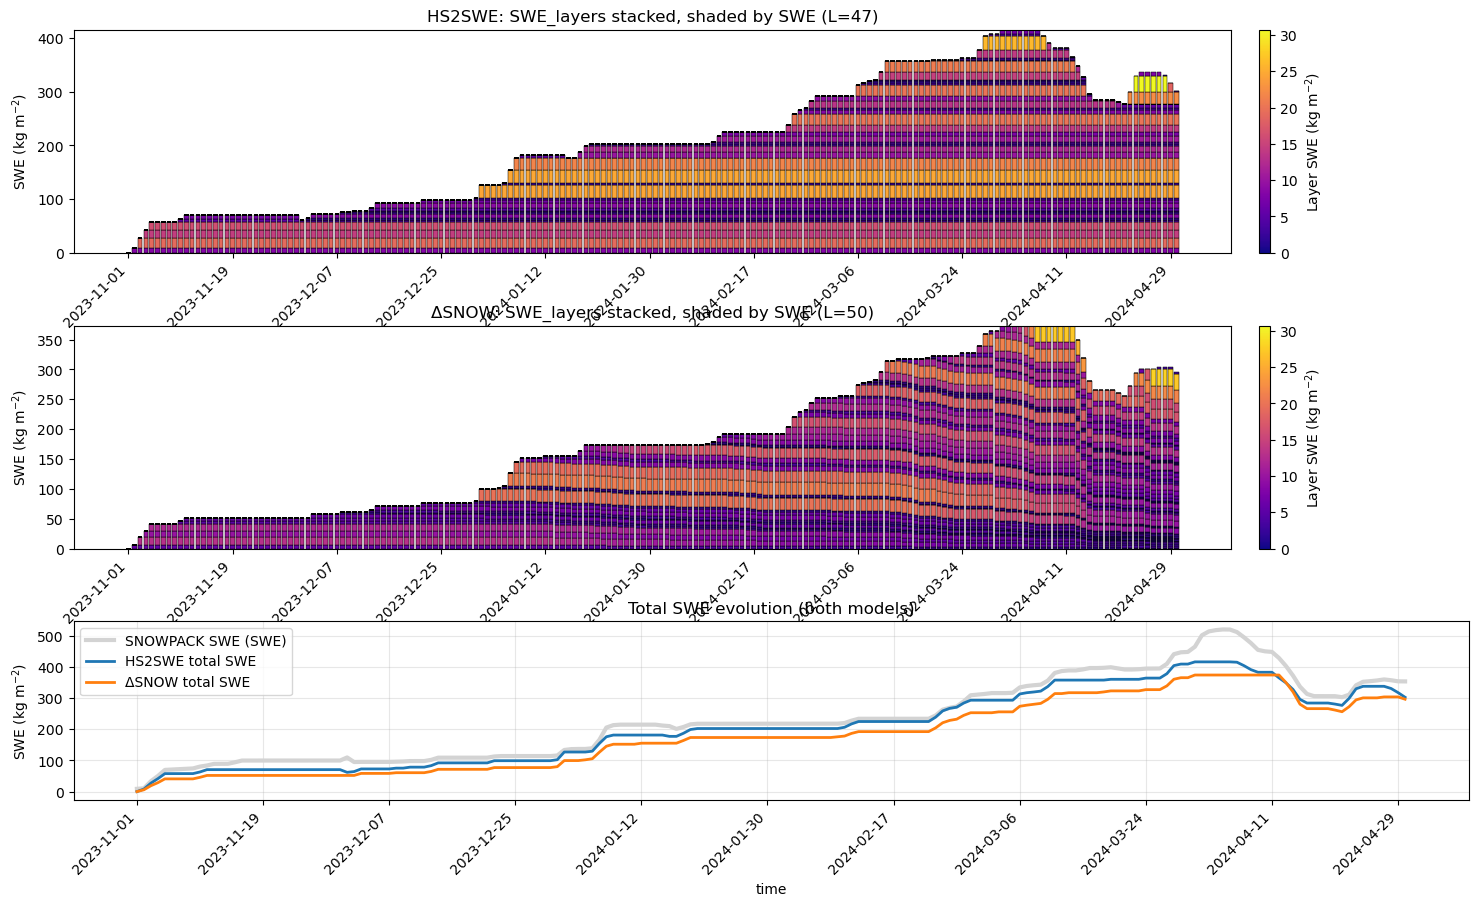


Common HS layers used: 46 / 47


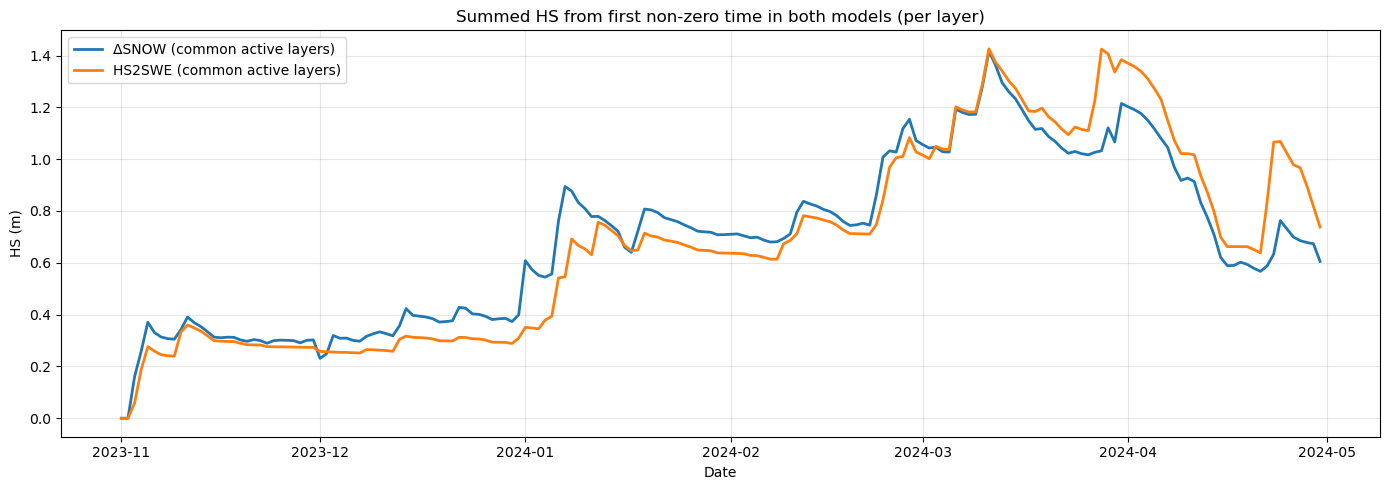

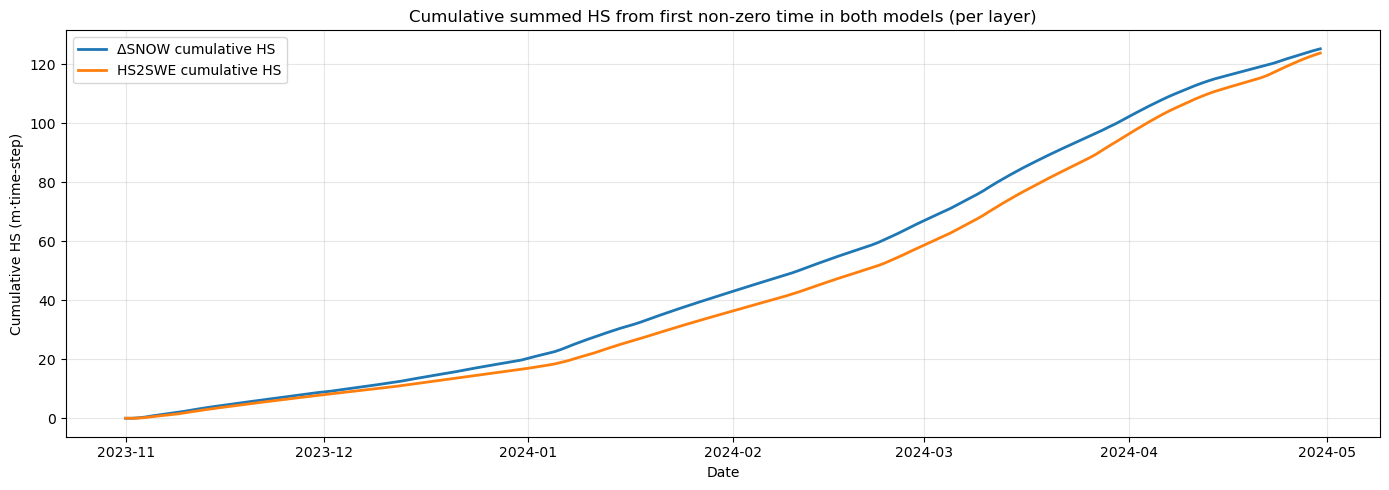


Common SWE layers used: 46 / 47
SNOWPACK SWE background used: True


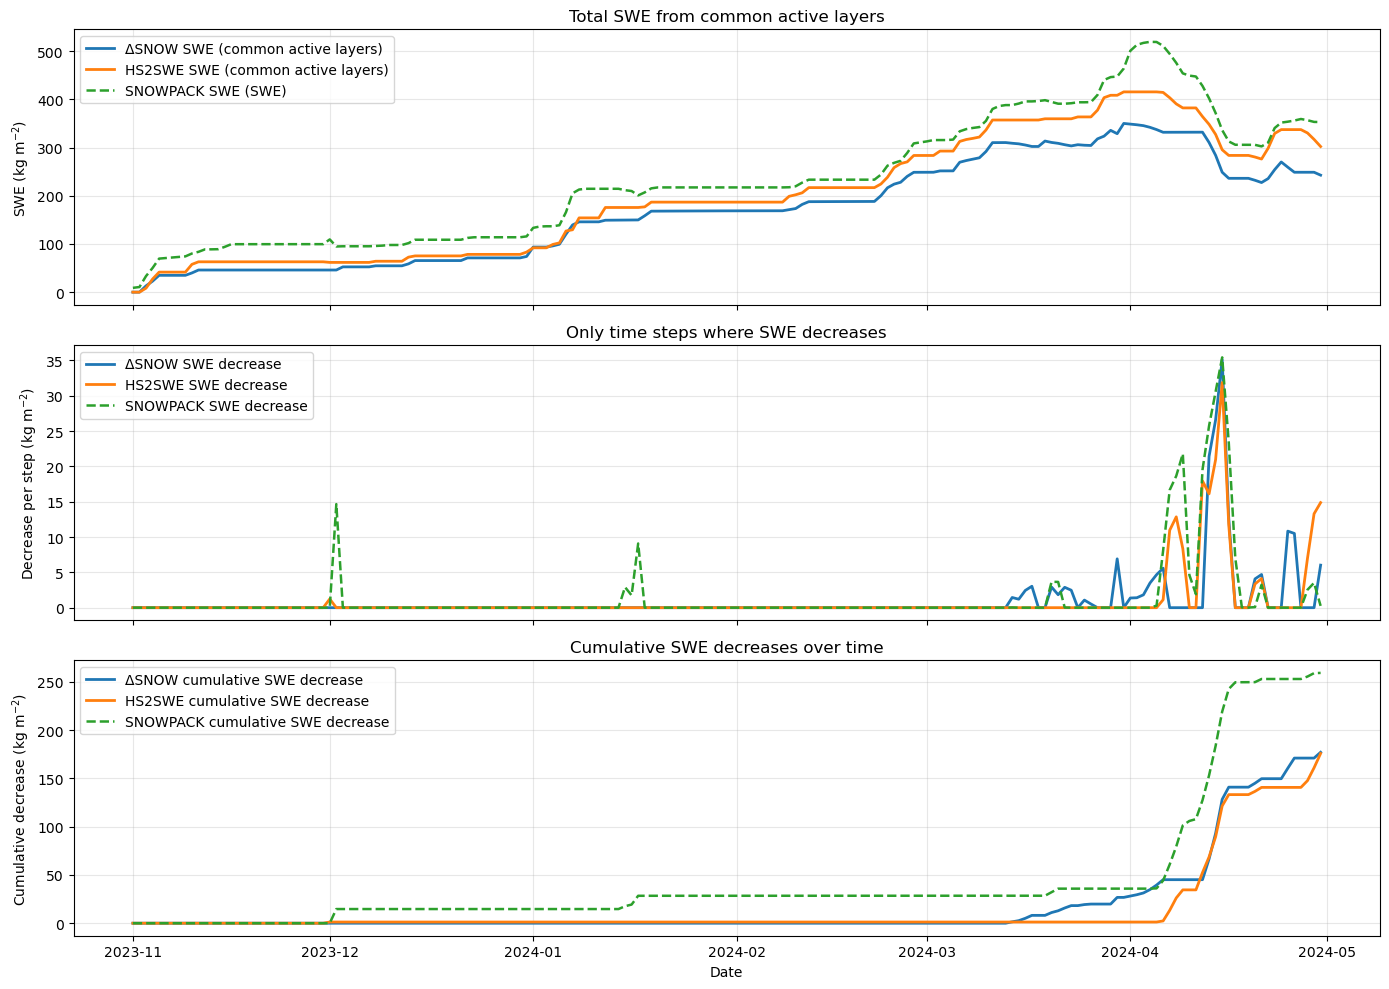

In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib as mpl
import matplotlib.pyplot as plt

# -----------------------------
# PATHS (edit if needed)
# -----------------------------
SNOWPACK_CSV = Path("/Users/jakobwerkgarner/code/mt_dsnow/par_sens/SNOWPACK_data_seasons_daily/OABS2_2023_2024_daily_HS_SWE.csv")
DSNOW_NC     = Path("/Users/jakobwerkgarner/code/mt_dsnow/model_diff/R_comparisson/output/SNOWPACK_forced/_dsnow_layers_OABS2_2023_2024.nc")
HS2SWE_NC    = Path("/Users/jakobwerkgarner/code/mt_dsnow/model_diff/R_comparisson/output/SNOWPACK_forced/_hs2swe_layers_OABS2_2023_2024.nc")

for p in [SNOWPACK_CSV, DSNOW_NC, HS2SWE_NC]:
    if not p.exists():
        raise FileNotFoundError(p)

# -----------------------------
# Helpers
# -----------------------------
def as_time_layer(da: xr.DataArray) -> np.ndarray:
    if tuple(da.dims) == ("time", "layer"):
        return da.values
    if tuple(da.dims) == ("layer", "time"):
        return np.swapaxes(da.values, 0, 1)
    raise ValueError(f"Unexpected dims for {da.name}: {da.dims}")

def flatten_nonzero(da: xr.DataArray) -> np.ndarray:
    a = as_time_layer(da).ravel()
    a = a[np.isfinite(a)]
    a = a[a != 0]
    return a

def stats_table(values: np.ndarray) -> pd.Series:
    v = np.asarray(values)
    v = v[np.isfinite(v)]
    if v.size == 0:
        return pd.Series(dtype=float)
    return pd.Series({
        "count": v.size,
        "mean": float(np.mean(v)),
        "std": float(np.std(v)),
        "min": float(np.min(v)),
        "p25": float(np.percentile(v, 25)),
        "median": float(np.percentile(v, 50)),
        "p75": float(np.percentile(v, 75)),
        "max": float(np.max(v)),
    })

def compare_stats(ds_a, ds_b, var):
    a = stats_table(flatten_nonzero(ds_a[var]))
    b = stats_table(flatten_nonzero(ds_b[var]))
    return pd.concat([a.rename(f"ΔSNOW.{var}"), b.rename(f"HS2SWE.{var}")], axis=1)

def total_over_layers(ds, var):
    A = as_time_layer(ds[var])
    return np.nansum(A, axis=1)

def get_time_labels(ds):
    ts = ds.attrs.get("timestamps", None)
    if ts is None:
        return np.arange(ds.sizes["time"]).astype(str)
    return np.array([s.strip() for s in ts.split(",")])

def first_nonzero_idx(col):
    idx = np.where(np.isfinite(col) & (col > 0))[0]
    return idx[0] if idx.size else np.nan

def pick_first_present(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None

def make_distinct_layer_colors(n_layers: int):
    """
    Distinct colors for many layers:
    - use HSV wheel evenly spaced (very distinct)
    - if n_layers <= 20, tab20 is already fine, but HSV is still okay
    """
    cmap = mpl.cm.get_cmap("hsv", n_layers)
    cols = cmap(np.arange(n_layers))
    # soften just a touch (optional) while keeping distinctness
    cols[:, 3] = 1.0
    return cols

# -----------------------------
# 1) Load data
# -----------------------------
snowpack = pd.read_csv(SNOWPACK_CSV)
if "timestamp" not in snowpack.columns:
    raise ValueError("SNOWPACK CSV must contain a 'timestamp' column.")

time_axis = pd.DatetimeIndex(pd.to_datetime(snowpack["timestamp"], errors="coerce"))

ds_dsnow  = xr.open_dataset(DSNOW_NC)
ds_hs2swe = xr.open_dataset(HS2SWE_NC)

# -----------------------------
# 2) Make variables comparable
# -----------------------------
# HS2SWE: HS in cm -> m, compute layer swe and total SWE
ds_hs2swe = ds_hs2swe.assign(HS=ds_hs2swe["HS"] / 100.0)
ds_hs2swe = ds_hs2swe.assign(swe=ds_hs2swe["RHO"] * ds_hs2swe["HS"])
ds_hs2swe["SWE"] = ds_hs2swe["swe"].sum(dim="layer")

# ΔSNOW: alias swe and compute RHO = swe/HS
ds_dsnow = ds_dsnow.assign(swe=ds_dsnow["SWE_layers"])
hs = ds_dsnow["HS"]
swe = ds_dsnow["swe"]
rho_ds = xr.where((hs > 0) & np.isfinite(hs) & np.isfinite(swe), swe / hs, np.nan)
ds_dsnow = ds_dsnow.assign(RHO=rho_ds)

# -----------------------------
# 3) Align lengths
# -----------------------------
n = min(len(time_axis), ds_dsnow.sizes["time"], ds_hs2swe.sizes["time"])
time_axis = time_axis[:n]

# -----------------------------
# 4) Optional SNOWPACK background series (grey)
# -----------------------------
hs_bg_col = pick_first_present(snowpack, [
    "HS_modelled", "HS_modeled", "HS_sim", "HS_model",
    "hs_modelled", "hs_modeled", "hs_sim", "hs_model"
])

swe_bg_col = pick_first_present(snowpack, [
    "SWE_modelled", "SWE_modeled", "SWE_sim", "SWE_model",
    "swe_modelled", "swe_modeled", "swe_sim", "swe_model"
])

if swe_bg_col is None:
    swe_cols = [c for c in snowpack.columns if "swe" in c.lower()]
    swe_bg_col = swe_cols[0] if swe_cols else None

hs_bg  = snowpack[hs_bg_col].to_numpy(dtype=float)[:n] if hs_bg_col else None
swe_bg = snowpack[swe_bg_col].to_numpy(dtype=float)[:n] if swe_bg_col else None

# -----------------------------
# 5) Stats (once)
# -----------------------------
print("\n==================== CASE: SNOWPACK_FORCED ====================")

print("\n=== HS stats (time×layer, NaN + zeros removed) ===")
print(compare_stats(ds_dsnow, ds_hs2swe, "HS"))

print("\n=== RHO stats (time×layer, NaN + zeros removed) ===")
print(compare_stats(ds_dsnow, ds_hs2swe, "RHO"))

print("\n=== OVB stats (time×layer, NaN + zeros removed) ===")
print(compare_stats(ds_dsnow, ds_hs2swe, "OVB"))

# -----------------------------
# 6) Plot: HS stacked by layer color (2 rows) - DISTINCT COLORS PER LAYER
# -----------------------------
HS_ds = as_time_layer(ds_dsnow["HS"]).astype(float)
HS_hs = as_time_layer(ds_hs2swe["HS"]).astype(float)

T = min(n, HS_ds.shape[0], HS_hs.shape[0])
HS_ds = np.where(np.isfinite(HS_ds[:T]), HS_ds[:T], 0.0)
HS_hs = np.where(np.isfinite(HS_hs[:T]), HS_hs[:T], 0.0)

L_max = max(HS_ds.shape[1], HS_hs.shape[1])
layer_colors = make_distinct_layer_colors(L_max)  # distinct for every layer

fig, axes = plt.subplots(2, 1, figsize=(16, 9), sharex=True)

for ax, H, title in [
    (axes[0], HS_ds, f"ΔSNOW: HS stacked by layer color (L={HS_ds.shape[1]})"),
    (axes[1], HS_hs, f"HS2SWE: HS stacked by layer color (L={HS_hs.shape[1]})"),
]:
    x = np.arange(T)
    bottom = np.zeros(T)
    for j in range(H.shape[1]):
        hj = H[:, j]
        if np.allclose(hj, 0.0):
            continue
        ax.bar(x, hj, bottom=bottom, color=layer_colors[j], edgecolor="black", linewidth=0.25)
        bottom += hj
    ax.set_ylabel("HS (m)")
    ax.grid(True, axis="y", alpha=0.3)
    ax.set_title(title)
    ax.text(
        0.01, 0.98, f"Layers: {H.shape[1]}",
        transform=ax.transAxes, ha="left", va="top", fontsize=11,
        bbox=dict(facecolor="white", edgecolor="black", alpha=0.6, boxstyle="round,pad=0.25")
    )

step = max(1, T // 10)
ticks = np.arange(0, T, step)
axes[1].set_xticks(ticks)
axes[1].set_xticklabels(time_axis[:T][ticks].strftime("%Y-%m-%d"), rotation=45, ha="right")
axes[1].set_xlabel("Date")

# layer colorbar
cmap_layers = mpl.colors.ListedColormap(layer_colors)
bounds = np.arange(0.5, L_max + 1.5, 1)
norm = mpl.colors.BoundaryNorm(bounds, cmap_layers.N)
sm = mpl.cm.ScalarMappable(cmap=cmap_layers, norm=norm)
sm.set_array([])

fig.subplots_adjust(right=0.88, bottom=0.12)
cax = fig.add_axes([0.90, 0.12, 0.02, 0.76])
tick_step = max(1, L_max // 10)
cbar = fig.colorbar(sm, cax=cax, ticks=np.arange(1, L_max + 1, tick_step))
cbar.set_label("Layer index")
plt.show()

# -----------------------------
# 7) Plot: Total HS (with SNOWPACK background)
# -----------------------------
hs_total_dsnow = total_over_layers(ds_dsnow, "HS")[:n]
hs_total_hs2   = total_over_layers(ds_hs2swe, "HS")[:n]

fig, ax = plt.subplots(figsize=(14, 5))

if hs_bg is not None:
    ax.fill_between(time_axis[:n], 0, hs_bg, color="lightgray", alpha=0.45,
                    label=f"SNOWPACK HS ({hs_bg_col})")

ax.plot(time_axis[:n], hs_total_dsnow, label="ΔSNOW total HS", linewidth=2)
ax.plot(time_axis[:n], hs_total_hs2,   label="HS2SWE total HS", linewidth=2)

ax.set_title("Total HS (sum over layers)")
ax.set_xlabel("Date")
ax.set_ylabel("HS (m)")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

# -----------------------------
# 8) Plot: Total SWE (with SNOWPACK background)
# -----------------------------
swe_dsnow = np.asarray(ds_dsnow["SWE"].values, dtype=float)[:n]
swe_hs2   = np.asarray(ds_hs2swe["SWE"].values, dtype=float)[:n]

fig, ax = plt.subplots(figsize=(14, 5))

if swe_bg is not None:
    ax.fill_between(time_axis[:n], 0, swe_bg, color="lightgray", alpha=0.45,
                    label=f"SNOWPACK SWE ({swe_bg_col})")

ax.plot(time_axis[:n], swe_dsnow, label="ΔSNOW SWE", linewidth=2)
ax.plot(time_axis[:n], swe_hs2,   label="HS2SWE SWE", linewidth=2)

ax.set_title("SWE comparison")
ax.set_xlabel("Date")
ax.set_ylabel("SWE (kg m$^{-2}$)")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

# -----------------------------
# 9) STACKED SWE layers + totals below (single case)
# -----------------------------
def stacked_bar(ax, heights_tl, shade_tl, title, ylabel, time_labels,
                cmap_name="plasma", edgecolor="black", linewidth=0.35,
                vmin=None, vmax=None):
    H = np.array(heights_tl, dtype=float)
    S = np.array(shade_tl, dtype=float)

    T_, L_ = H.shape
    x = np.arange(T_)

    H = np.where(np.isfinite(H), H, 0.0)
    S = np.where(np.isfinite(S), S, np.nan)

    if vmin is None:
        vmin = np.nanmin(S)
    if vmax is None:
        vmax = np.nanmax(S)
    if (not np.isfinite(vmin)) or (not np.isfinite(vmax)) or (vmin == vmax):
        vmin, vmax = 0.0, 1.0

    norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
    cmap_ = mpl.cm.get_cmap(cmap_name)

    bottom = np.zeros(T_)
    for j in range(L_):
        hj = H[:, j]
        if np.allclose(hj, 0.0):
            continue
        cols = cmap_(norm(S[:, j]))
        ax.bar(x, hj, bottom=bottom, color=cols, edgecolor=edgecolor, linewidth=linewidth)
        bottom += hj

    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.set_xlabel("time")

    step = max(1, int(len(time_labels) / 10))
    ticks = np.arange(0, len(time_labels), step)
    ax.set_xticks(ticks)
    ax.set_xticklabels(time_labels[ticks], rotation=45, ha="right")

    sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap_)
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, pad=0.02)
    return cbar

SWE_layers_hs2 = as_time_layer(ds_hs2swe["swe"])[:n, :]
SWE_layers_ds  = as_time_layer(ds_dsnow["SWE_layers"])[:n, :]

swe_min = np.nanmin([np.nanmin(SWE_layers_hs2), np.nanmin(SWE_layers_ds)])
swe_max = np.nanmax([np.nanmax(SWE_layers_hs2), np.nanmax(SWE_layers_ds)])

time_labels = get_time_labels(ds_dsnow)

fig = plt.figure(figsize=(18, 10))
gs = fig.add_gridspec(3, 1, height_ratios=[1, 1, 0.8], hspace=0.35)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[1, 0])
ax3 = fig.add_subplot(gs[2, 0])

cbar1 = stacked_bar(
    ax=ax1,
    heights_tl=SWE_layers_hs2,
    shade_tl=SWE_layers_hs2,
    title=f"HS2SWE: SWE_layers stacked, shaded by SWE (L={SWE_layers_hs2.shape[1]})",
    ylabel="SWE (kg m$^{-2}$)",
    time_labels=time_labels,
    cmap_name="plasma",
    vmin=swe_min,
    vmax=swe_max
)
cbar1.set_label("Layer SWE (kg m$^{-2}$)")

cbar2 = stacked_bar(
    ax=ax2,
    heights_tl=SWE_layers_ds,
    shade_tl=SWE_layers_ds,
    title=f"ΔSNOW: SWE_layers stacked, shaded by SWE (L={SWE_layers_ds.shape[1]})",
    ylabel="SWE (kg m$^{-2}$)",
    time_labels=time_labels,
    cmap_name="plasma",
    vmin=swe_min,
    vmax=swe_max
)
cbar2.set_label("Layer SWE (kg m$^{-2}$)")

x = np.arange(n)
if swe_bg is not None:
    ax3.plot(x, swe_bg[:n], color="lightgray", linewidth=3, label=f"SNOWPACK SWE ({swe_bg_col})")
ax3.plot(x, swe_hs2[:n],   label="HS2SWE total SWE", linewidth=2)
ax3.plot(x, swe_dsnow[:n], label="ΔSNOW total SWE", linewidth=2)
ax3.set_title("Total SWE evolution (both models)")
ax3.set_xlabel("time")
ax3.set_ylabel("SWE (kg m$^{-2}$)")
ax3.grid(True, alpha=0.3)
ax3.legend()

step = max(1, int(len(time_labels) / 10))
ticks = np.arange(0, len(time_labels), step)
ax3.set_xticks(ticks)
ax3.set_xticklabels(time_labels[ticks], rotation=45, ha="right")

plt.tight_layout()
plt.show()

# -----------------------------
# 10) COMMON ACTIVE HS (summed + cumulative)
# -----------------------------
def common_active_hs(ds_dsnow, ds_hs2swe, time_axis):
    HS_ds = as_time_layer(ds_dsnow["HS"]).astype(float)
    HS_hs = as_time_layer(ds_hs2swe["HS"]).astype(float)

    T_ = min(HS_ds.shape[0], HS_hs.shape[0], len(time_axis))
    L_ = min(HS_ds.shape[1], HS_hs.shape[1])

    HS_ds = HS_ds[:T_, :L_]
    HS_hs = HS_hs[:T_, :L_]

    first_ds = np.array([first_nonzero_idx(HS_ds[:, j]) for j in range(L_)], dtype=float)
    first_hs = np.array([first_nonzero_idx(HS_hs[:, j]) for j in range(L_)], dtype=float)

    common_layers = np.isfinite(first_ds) & np.isfinite(first_hs)
    start_idx = np.maximum(first_ds, first_hs)

    t_idx = np.arange(T_)[:, None]
    active_mask = common_layers[None, :] & (t_idx >= start_idx[None, :])

    hs_sum_ds_common = np.nansum(np.where(active_mask, HS_ds, 0.0), axis=1)
    hs_sum_hs_common = np.nansum(np.where(active_mask, HS_hs, 0.0), axis=1)

    hs_cum_ds_common = np.cumsum(np.nan_to_num(hs_sum_ds_common, nan=0.0))
    hs_cum_hs_common = np.cumsum(np.nan_to_num(hs_sum_hs_common, nan=0.0))

    return dict(
        T=T_, L=L_,
        common_layers=common_layers,
        hs_sum_ds=hs_sum_ds_common,
        hs_sum_hs=hs_sum_hs_common,
        hs_cum_ds=hs_cum_ds_common,
        hs_cum_hs=hs_cum_hs_common
    )

hs_common = common_active_hs(ds_dsnow, ds_hs2swe, time_axis)
print(f"\nCommon HS layers used: {int(hs_common['common_layers'].sum())} / {hs_common['L']}")

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(time_axis[:hs_common["T"]], hs_common["hs_sum_ds"], label="ΔSNOW (common active layers)", linewidth=2)
ax.plot(time_axis[:hs_common["T"]], hs_common["hs_sum_hs"], label="HS2SWE (common active layers)", linewidth=2)
ax.set_title("Summed HS from first non-zero time in both models (per layer)")
ax.set_xlabel("Date")
ax.set_ylabel("HS (m)")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(time_axis[:hs_common["T"]], hs_common["hs_cum_ds"], label="ΔSNOW cumulative HS", linewidth=2)
ax.plot(time_axis[:hs_common["T"]], hs_common["hs_cum_hs"], label="HS2SWE cumulative HS", linewidth=2)
ax.set_title("Cumulative summed HS from first non-zero time in both models (per layer)")
ax.set_xlabel("Date")
ax.set_ylabel("Cumulative HS (m·time-step)")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

# -----------------------------
# 11) COMMON ACTIVE SWE + DECREASE METRICS (3 rows x 1 col)
# -----------------------------
def common_active_swe_and_decrease(ds_dsnow, ds_hs2swe, time_axis, snowpack_df=None, swe_bg_col=None):
    SWE_ds = as_time_layer(ds_dsnow["swe"]).astype(float)
    SWE_hs = as_time_layer(ds_hs2swe["swe"]).astype(float)

    T_ = min(SWE_ds.shape[0], SWE_hs.shape[0], len(time_axis))
    L_ = min(SWE_ds.shape[1], SWE_hs.shape[1])

    SWE_ds = SWE_ds[:T_, :L_]
    SWE_hs = SWE_hs[:T_, :L_]

    first_ds_swe = np.array([first_nonzero_idx(SWE_ds[:, j]) for j in range(L_)], dtype=float)
    first_hs_swe = np.array([first_nonzero_idx(SWE_hs[:, j]) for j in range(L_)], dtype=float)

    common_layers_swe = np.isfinite(first_ds_swe) & np.isfinite(first_hs_swe)
    start_idx_swe = np.maximum(first_ds_swe, first_hs_swe)

    t_idx = np.arange(T_)[:, None]
    active_mask_swe = common_layers_swe[None, :] & (t_idx >= start_idx_swe[None, :])

    swe_sum_ds_common = np.nansum(np.where(active_mask_swe, SWE_ds, 0.0), axis=1)
    swe_sum_hs_common = np.nansum(np.where(active_mask_swe, SWE_hs, 0.0), axis=1)

    ds_delta = np.diff(swe_sum_ds_common, prepend=np.nan)
    hs_delta = np.diff(swe_sum_hs_common, prepend=np.nan)

    ds_decrease = np.where(ds_delta < 0, -ds_delta, 0.0)
    hs_decrease = np.where(hs_delta < 0, -hs_delta, 0.0)

    ds_cum_decrease = np.nancumsum(ds_decrease)
    hs_cum_decrease = np.nancumsum(hs_decrease)

    have_obs = (snowpack_df is not None) and (swe_bg_col is not None) and (swe_bg_col in snowpack_df.columns)
    if have_obs:
        swe_obs = snowpack_df[swe_bg_col].to_numpy(dtype=float)
        T_obs = min(T_, len(swe_obs))
        swe_obs_T = swe_obs[:T_obs]

        obs_delta = np.diff(swe_obs_T, prepend=np.nan)
        obs_decrease = np.where(obs_delta < 0, -obs_delta, 0.0)
        obs_cum_decrease = np.nancumsum(obs_decrease)
    else:
        T_obs = T_
        swe_obs_T = None
        obs_decrease = None
        obs_cum_decrease = None

    return dict(
        T=T_, L=L_,
        common_layers_swe=common_layers_swe,
        swe_sum_ds=swe_sum_ds_common,
        swe_sum_hs=swe_sum_hs_common,
        ds_decrease=ds_decrease,
        hs_decrease=hs_decrease,
        ds_cum_decrease=ds_cum_decrease,
        hs_cum_decrease=hs_cum_decrease,
        have_obs=have_obs,
        T_obs=T_obs,
        swe_obs_T=swe_obs_T,
        obs_decrease=obs_decrease,
        obs_cum_decrease=obs_cum_decrease
    )

swe_common = common_active_swe_and_decrease(ds_dsnow, ds_hs2swe, time_axis, snowpack_df=snowpack, swe_bg_col=swe_bg_col)
print(f"\nCommon SWE layers used: {int(swe_common['common_layers_swe'].sum())} / {swe_common['L']}")
print(f"SNOWPACK SWE background used: {swe_common['have_obs']}")

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# 1) total SWE
axes[0].plot(time_axis[:swe_common["T"]], swe_common["swe_sum_ds"], label="ΔSNOW SWE (common active layers)", linewidth=2)
axes[0].plot(time_axis[:swe_common["T"]], swe_common["swe_sum_hs"], label="HS2SWE SWE (common active layers)", linewidth=2)
if swe_common["have_obs"]:
    axes[0].plot(time_axis[:swe_common["T_obs"]], swe_common["swe_obs_T"], label=f"SNOWPACK SWE ({swe_bg_col})", linestyle="--", linewidth=1.8)
axes[0].set_ylabel("SWE (kg m$^{-2}$)")
axes[0].set_title("Total SWE from common active layers")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# 2) SWE decreases only
axes[1].plot(time_axis[:swe_common["T"]], swe_common["ds_decrease"], label="ΔSNOW SWE decrease", linewidth=2)
axes[1].plot(time_axis[:swe_common["T"]], swe_common["hs_decrease"], label="HS2SWE SWE decrease", linewidth=2)
if swe_common["have_obs"]:
    axes[1].plot(time_axis[:swe_common["T_obs"]], swe_common["obs_decrease"], label="SNOWPACK SWE decrease", linestyle="--", linewidth=1.8)
axes[1].set_ylabel("Decrease per step (kg m$^{-2}$)")
axes[1].set_title("Only time steps where SWE decreases")
axes[1].grid(True, alpha=0.3)
axes[1].legend()

# 3) cumulative decreases
axes[2].plot(time_axis[:swe_common["T"]], swe_common["ds_cum_decrease"], label="ΔSNOW cumulative SWE decrease", linewidth=2)
axes[2].plot(time_axis[:swe_common["T"]], swe_common["hs_cum_decrease"], label="HS2SWE cumulative SWE decrease", linewidth=2)
if swe_common["have_obs"]:
    axes[2].plot(time_axis[:swe_common["T_obs"]], swe_common["obs_cum_decrease"], label="SNOWPACK cumulative SWE decrease", linestyle="--", linewidth=1.8)
axes[2].set_ylabel("Cumulative decrease (kg m$^{-2}$)")
axes[2].set_title("Cumulative SWE decreases over time")
axes[2].set_xlabel("Date")
axes[2].grid(True, alpha=0.3)
axes[2].legend()

plt.tight_layout()
plt.show()

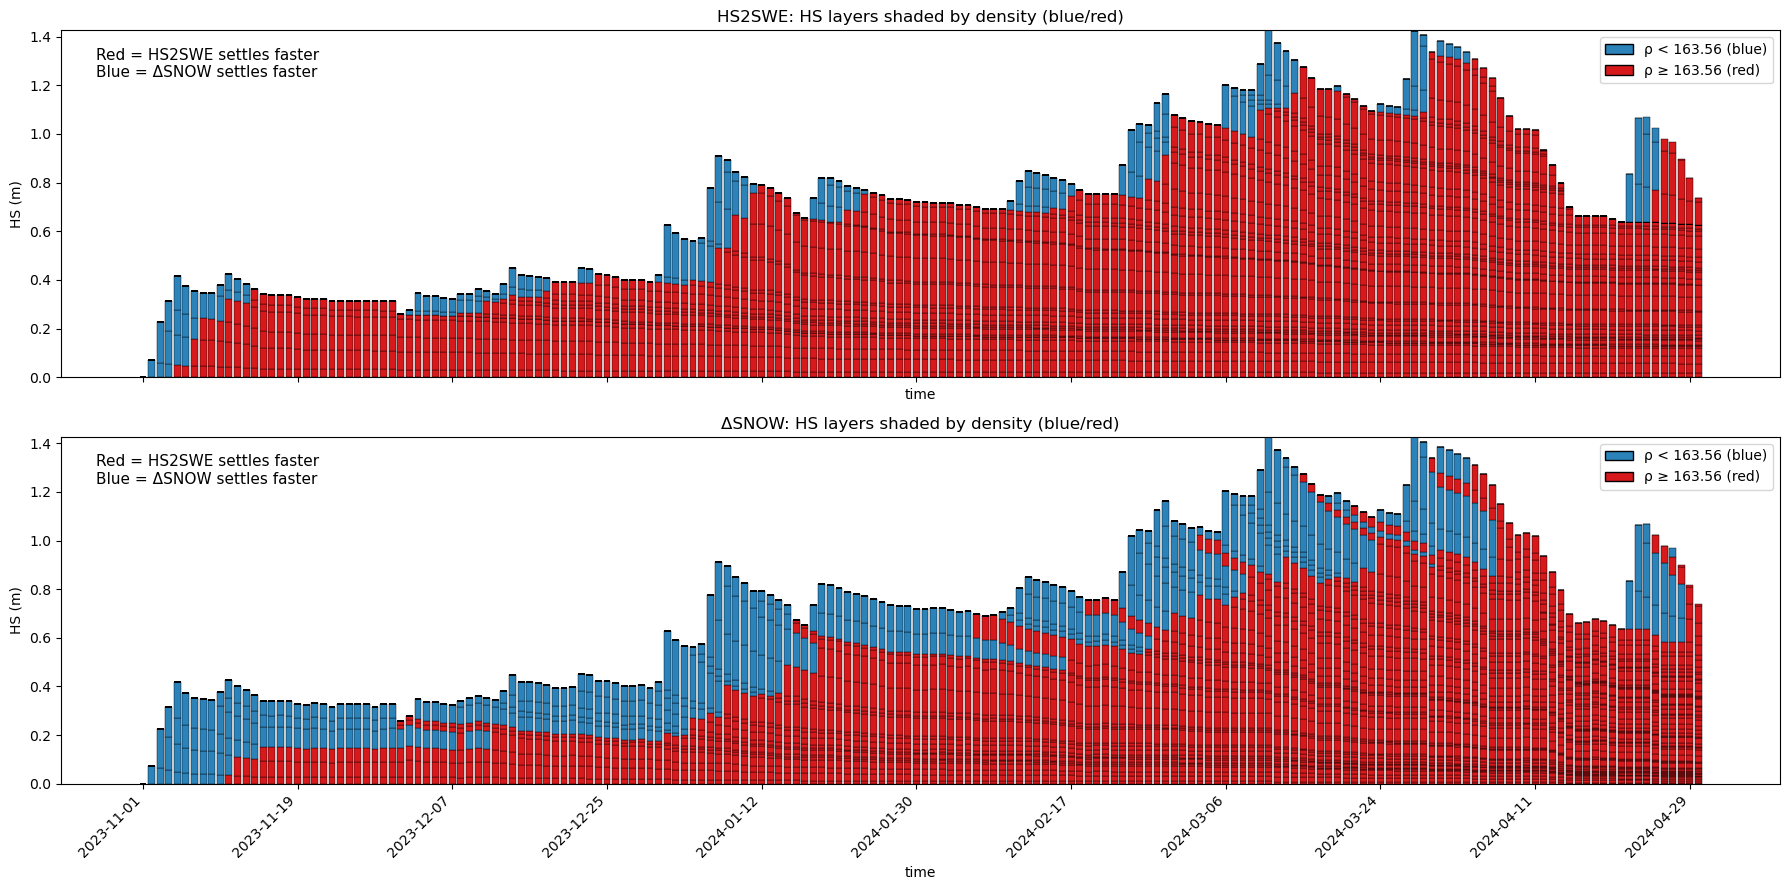

In [18]:
from matplotlib.patches import Patch

def plot_hs_stacked_binary_rho_ax(ax, ds, model_name, time_labels,
                                 center=163.56,
                                 low_color="#2b83ba",
                                 high_color="#d7191c"):
    HS = as_time_layer(ds["HS"]).astype(float)
    RHO = as_time_layer(ds["RHO"]).astype(float)

    T, L = HS.shape
    x = np.arange(T)
    bottom = np.zeros(T)

    HS = np.where(np.isfinite(HS), HS, 0.0)

    for j in range(L):
        hj = HS[:, j]
        if np.allclose(hj, 0.0):
            continue

        rho_j = RHO[:, j]
        colors = np.where(rho_j < center, low_color, high_color)
        colors = np.where(np.isfinite(rho_j), colors, "#cccccc")

        ax.bar(
            x, hj, bottom=bottom,
            color=colors,
            edgecolor="black",
            linewidth=0.3
        )
        bottom += hj

    ax.set_title(f"{model_name}: HS layers shaded by density (blue/red)")
    ax.set_xlabel("time")
    ax.set_ylabel("HS (m)")

    step = max(1, int(len(time_labels) / 10))
    ticks = np.arange(0, len(time_labels), step)
    ax.set_xticks(ticks)
    ax.set_xticklabels(np.asarray(time_labels)[ticks], rotation=45, ha="right")

    legend_elements = [
        Patch(facecolor=low_color, edgecolor="black", label=f"ρ < {center:.2f} (blue)"),
        Patch(facecolor=high_color, edgecolor="black", label=f"ρ ≥ {center:.2f} (red)")
    ]
    ax.legend(handles=legend_elements, loc="upper right")

    ax.text(0.02, 0.95, "Red = HS2SWE settles faster",
            transform=ax.transAxes, fontsize=11, verticalalignment="top")
    ax.text(0.02, 0.90, "Blue = ΔSNOW settles faster",
            transform=ax.transAxes, fontsize=11, verticalalignment="top")


# --- run plot (single case)
time_labels = get_time_labels(ds_dsnow)  # use ds_dsnow attrs as reference

center = 163.56
low_color = "#2b83ba"
high_color = "#d7191c"

fig, axes = plt.subplots(2, 1, figsize=(18, 9), sharex=True, sharey=True)

plot_hs_stacked_binary_rho_ax(
    axes[0], ds_hs2swe, "HS2SWE", time_labels,
    center=center, low_color=low_color, high_color=high_color
)
plot_hs_stacked_binary_rho_ax(
    axes[1], ds_dsnow, "ΔSNOW", time_labels,
    center=center, low_color=low_color, high_color=high_color
)

plt.tight_layout()
plt.show()

/var/folders/r5/2d5m4_zn37d74npwnbfcpcdh0000gn/T/ipykernel_6600/3707014148.py:15: RuntimeWarning: Mean of empty slice
  rho_low_ds = np.nanmean(as_time_layer(ds_dsnow_low["RHO"]), axis=1)


ΔSNOW selected layers: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18]
HS2SWE selected layers: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20]


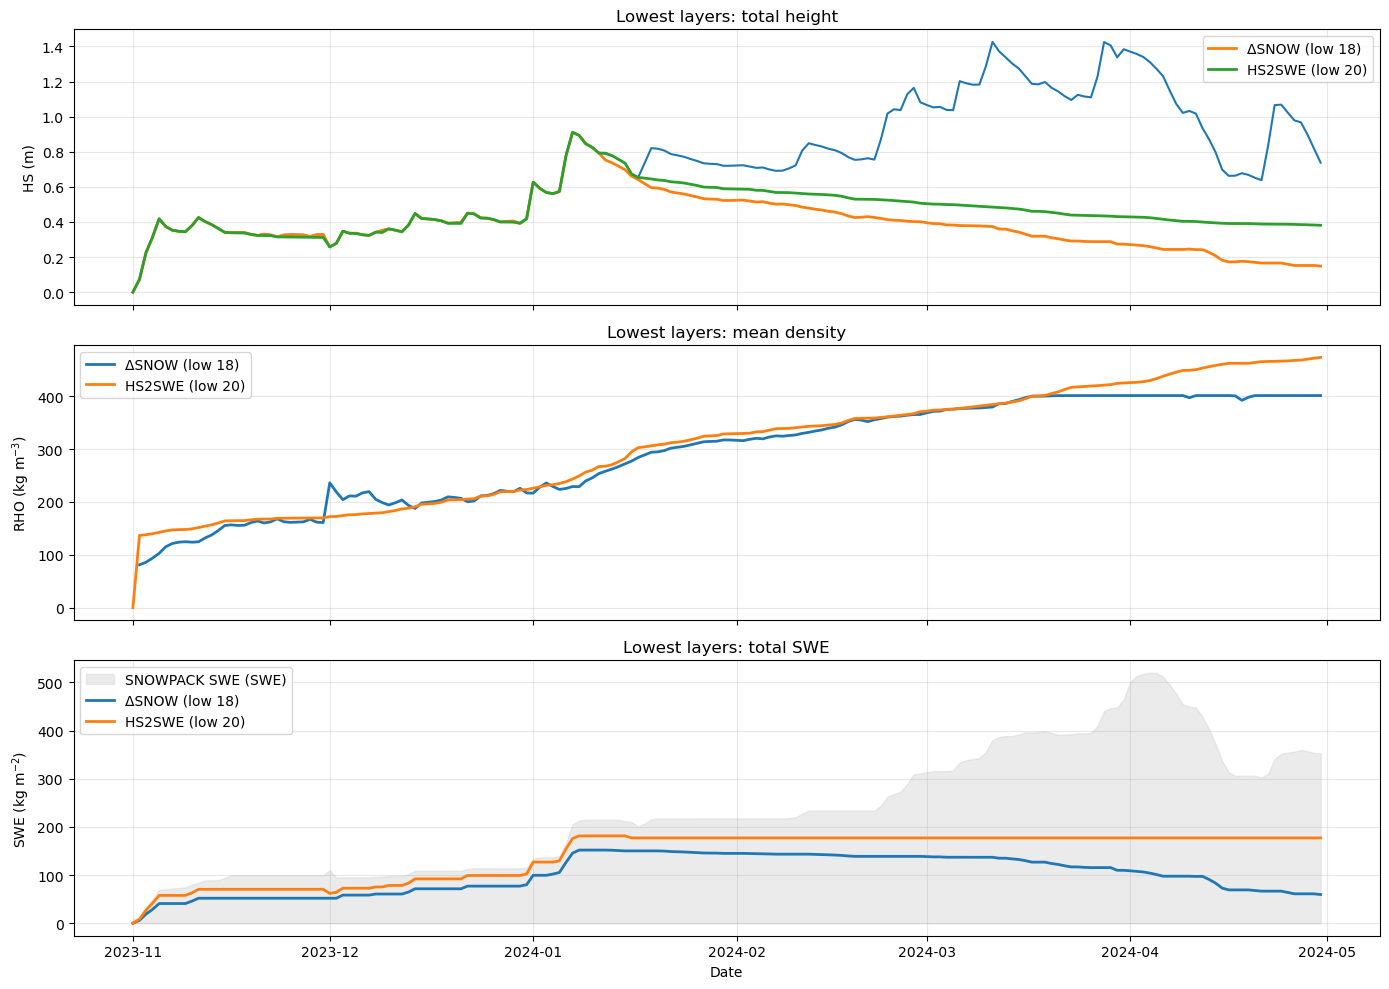

SNOWPACK HS background used : False
SNOWPACK SWE background used: True


In [28]:
# %%
# Lowest-layers plot WITH SNOWPACK HS background (and SWE background if available)

# USER SETTINGS
lowest_n_ds = 18   # ΔSNOW: number of lowest layers
lowest_n_hs = 20 # HS2SWE: number of lowest layers

def build_low_layer_series(ds_dsnow, ds_hs2swe, lowest_n_ds, lowest_n_hs):
    ds_dsnow_low  = ds_dsnow.isel(layer=slice(0, lowest_n_ds))
    ds_hs2swe_low = ds_hs2swe.isel(layer=slice(0, lowest_n_hs))

    hs_low_ds = np.nansum(as_time_layer(ds_dsnow_low["HS"]), axis=1)
    hs_low_hs = np.nansum(as_time_layer(ds_hs2swe_low["HS"]), axis=1)

    rho_low_ds = np.nanmean(as_time_layer(ds_dsnow_low["RHO"]), axis=1)
    rho_low_hs = np.nanmean(as_time_layer(ds_hs2swe_low["RHO"]), axis=1)

    swe_low_ds = np.nansum(as_time_layer(ds_dsnow_low["swe"]), axis=1)
    swe_low_hs = np.nansum(as_time_layer(ds_hs2swe_low["swe"]), axis=1)

    return dict(
        ds_layers=ds_dsnow_low["layer"].values,
        hs_layers=ds_hs2swe_low["layer"].values,
        hs_low_ds=hs_low_ds, hs_low_hs=hs_low_hs,
        rho_low_ds=rho_low_ds, rho_low_hs=rho_low_hs,
        swe_low_ds=swe_low_ds, swe_low_hs=swe_low_hs
    )

low = build_low_layer_series(ds_dsnow, ds_hs2swe, lowest_n_ds, lowest_n_hs)

print("ΔSNOW selected layers:", low["ds_layers"])
print("HS2SWE selected layers:", low["hs_layers"])

have_hs_bg  = ("hs_bg" in globals()) and (hs_bg is not None)
have_swe_bg = ("swe_bg" in globals()) and (swe_bg is not None)

n_plot = min(
    n,
    len(low["hs_low_ds"]), len(low["hs_low_hs"]),
    len(low["rho_low_ds"]), len(low["rho_low_hs"]),
    len(low["swe_low_ds"]), len(low["swe_low_hs"])
)
if have_hs_bg:
    n_plot = min(n_plot, len(hs_bg))
if have_swe_bg:
    n_plot = min(n_plot, len(swe_bg))

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# HS panel (SNOWPACK background in grey)
axes[0].plot(time_axis, snowpack['HS_meas'])
axes[0].plot(time_axis[:n_plot], low["hs_low_ds"][:n_plot],
             label=f"ΔSNOW (low {lowest_n_ds})", linewidth=2)
axes[0].plot(time_axis[:n_plot], low["hs_low_hs"][:n_plot],
             label=f"HS2SWE (low {lowest_n_hs})", linewidth=2)
axes[0].set_ylabel("HS (m)")
axes[0].set_title("Lowest layers: total height")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# Density panel
axes[1].plot(time_axis[:n_plot], low["rho_low_ds"][:n_plot],
             label=f"ΔSNOW (low {lowest_n_ds})", linewidth=2)
axes[1].plot(time_axis[:n_plot], low["rho_low_hs"][:n_plot],
             label=f"HS2SWE (low {lowest_n_hs})", linewidth=2)
axes[1].set_ylabel("RHO (kg m$^{-3}$)")
axes[1].set_title("Lowest layers: mean density")
axes[1].grid(True, alpha=0.3)
axes[1].legend()

# SWE panel (SNOWPACK background in grey if available)
if have_swe_bg:
    axes[2].fill_between(
        time_axis[:n_plot], 0, swe_bg[:n_plot],
        color="lightgray", alpha=0.45,
        label=f"SNOWPACK SWE ({swe_bg_col})" if ("swe_bg_col" in globals() and swe_bg_col) else "SNOWPACK SWE"
    )
axes[2].plot(time_axis[:n_plot], low["swe_low_ds"][:n_plot],
             label=f"ΔSNOW (low {lowest_n_ds})", linewidth=2)
axes[2].plot(time_axis[:n_plot], low["swe_low_hs"][:n_plot],
             label=f"HS2SWE (low {lowest_n_hs})", linewidth=2)
axes[2].set_ylabel("SWE (kg m$^{-2}$)")
axes[2].set_title("Lowest layers: total SWE")
axes[2].grid(True, alpha=0.3)
axes[2].legend()
axes[2].set_xlabel("Date")

plt.tight_layout()
plt.show()

print(f"SNOWPACK HS background used : {have_hs_bg}")
print(f"SNOWPACK SWE background used: {have_swe_bg}")

In [24]:
snowpack['HS_meas']

0      0.000000
1      0.072583
2      0.225459
3      0.314337
4      0.417876
         ...   
177    0.978667
178    0.967375
179    0.897625
180    0.817542
181    0.737875
Name: HS_meas, Length: 182, dtype: float64